# CSCE 676 Project Checkpoint 2: Research Question Formation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)


BEHAVIORS_PATH = "behaviors.tsv"
NEWS_PATH = "news.tsv"


## 1. Project Scope

**Dataset:**
I used the MIND-small dataset, which contains user news browsing histories. Each record includes a sequence of news articles clicked by a user. For this project, article IDs are mapped to their corresponding news categories, allowing us to analyze user behavior at a higher, more interpretable level. The data is transformed into:

- Transaction-style data (sets of categories per user)

- Sequential data (ordered category sequences per user)

**EDA Findings:**
Initial exploratory analysis revealed several key characteristics:

- The raw article space is highly sparse, but category-level aggregation reduces sparsity and makes patterns more tractable.

- User histories exhibit varying lengths, with many short sessions and some longer sequences suitable for sequential analysis.

- Category distributions are imbalanced, with a few dominant categories and a long tail of less frequent ones.

- Evidence of repeated and clustered category interactions suggests both co-occurrence structure and temporal ordering effects.


For this checkpoint, I specifically examined these two files:

- `behaviors.tsv`: user interaction logs, impression timestamps, and prior click history
- `news.tsv`: article metadata including category, subcategory, title, and abstract

These are sufficient for a research-question formation because they allow me to reason about:
- **item co-occurrence** (frequent itemsets / association rules),
- **temporal click order** (sequential pattern mining),
- **semantic aggregation** via article categories and subcategories.


In [2]:
behaviors = pd.read_csv(
    BEHAVIORS_PATH,
    sep="\t",
    header=None,
    names=["impression_id", "user_id", "time", "history", "impressions"]
)

news = pd.read_csv(
    NEWS_PATH,
    sep="\t",
    header=None,
    names=[
        "news_id", "category", "subcategory", "title", "abstract",
        "url", "title_entities", "abstract_entities"
    ]
)

behaviors["time"] = pd.to_datetime(behaviors["time"], errors="coerce")

print("behaviors shape:", behaviors.shape)
print("news shape:", news.shape)
print("\nbehaviors sample:")
display(behaviors.head(3))
print("\nnews sample:")
display(news.head(3))


behaviors shape: (156965, 5)
news shape: (51282, 8)

behaviors sample:


,impression_id,user_id,time,history,impressions
0,1,U13740,2019-11-11 09:05:58,N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0
1,2,U91836,2019-11-12 18:11:30,N31739 N6072 N63045 N23979 N35656 N43353 N8129 N1569 N17686 N13008 N21623 N6233 N14340 N48031 N62285 N44383 N23061 N...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N22407-0 N14592-0 N17059-1 N33677-0 N7821-0 N6890-0
2,3,U73700,2019-11-14 07:01:48,N10732 N25792 N7563 N21087 N41087 N5445 N60384 N46616 N52500 N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N59685-0 N23814-1 N23446-0 N64174-0 N11817-0 N60550-0 N48225-0 N45509-0...



news sample:


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By","Shop the notebooks, jackets, and more that the royals can't live without.",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"", ""Type"": ""P"", ""WikidataId"": ""Q80976"", ""Confidence"": 1.0, ""OccurrenceOf...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding you back and keeping you from shedding that unwanted belly fat for good.,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""WikidataId"": ""Q193583"", ""Confidence"": 1.0, ""OccurrenceOffsets"": [20], ""Su...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""WikidataId"": ""Q193583"", ""Confidence"": 1.0, ""OccurrenceOffsets"": [97], ""Su..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches of Ukraine's War,Lt. Ivan Molchanets peeked over a parapet of sand bags at the front line of the war in Ukraine. Next to him was an e...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId"": ""Q212"", ""Confidence"": 0.946, ""OccurrenceOffsets"": [87], ""SurfaceFor..."


### Why this representation matters

MIND-small is not a retail-basket dataset, so I need to **define what counts as an itemset transaction and what counts as a sequence**.

I use the following mapping:

- **Transaction for itemset/rule mining:** the set of categories appearing in a behavior row's click history.
- **Sequence for sequential mining:** the ordered category sequence from that same history.

I  aggregate from **article IDs** to **categories** for the main feasibility experiments because:

1. Article-level space is extremely sparse in MIND-small.  
2. Category-level patterns are more interpretable for a checkpoint focused on RQ formation.  
3. This choice makes Apriori-style mining feasible without hiding the real structure of the dataset.


In [3]:
# Parse histories into lists of clicked article ids.
behaviors["history_list"] = behaviors["history"].fillna("").str.split()

# Create mapping from article id -> category and subcategory.
category_map = news.set_index("news_id")["category"].to_dict()
subcategory_map = news.set_index("news_id")["subcategory"].to_dict()

# Map history article ids into category and subcategory sequences.
behaviors["category_sequence_raw"] = behaviors["history_list"].apply(
    lambda ids: [category_map[x] for x in ids if x in category_map]
)
behaviors["subcategory_sequence_raw"] = behaviors["history_list"].apply(
    lambda ids: [subcategory_map[x] for x in ids if x in subcategory_map]
)

behaviors["history_len"] = behaviors["history_list"].str.len()
behaviors["category_seq_len"] = behaviors["category_sequence_raw"].str.len()

summary = pd.DataFrame({
    "metric": [
        "rows in behaviors",
        "unique users",
        "rows with empty history",
        "unique article ids in news",
        "unique categories in news",
        "unique subcategories in news"
    ],
    "value": [
        len(behaviors),
        behaviors["user_id"].nunique(),
        int((behaviors["history_len"] == 0).sum()),
        news["news_id"].nunique(),
        news["category"].nunique(),
        news["subcategory"].nunique()
    ]
})
display(summary)


,metric,value
0,rows in behaviors,156965
1,unique users,50000
2,rows with empty history,3238
3,unique article ids in news,51282
4,unique categories in news,17
5,unique subcategories in news,264


## 2. Additional EDA

I performed additional EDA in order to better understand these topics:

- Is the click history long enough to support sequence mining?
- Is article-level mining too sparse?
- Are category-level patterns likely to be interpretable?
- Are there enough repeated behaviors for pattern mining to be meaningful?


In [4]:
# Article-space sparsity versus category-space compactness.
all_history_article_ids = [x for seq in behaviors["history_list"] for x in seq]
all_history_categories = [x for seq in behaviors["category_sequence_raw"] for x in seq]

article_counter = Counter(all_history_article_ids)
category_counter = Counter(all_history_categories)

eda_cardinality = pd.DataFrame({
    "representation": ["article ids", "categories"],
    "unique_items_in_histories": [len(article_counter), len(category_counter)],
    "top_item_share": [
        max(article_counter.values()) / max(1, len(all_history_article_ids)),
        max(category_counter.values()) / max(1, len(all_history_categories))
    ]
})
display(eda_cardinality)

print("Top 10 categories by raw frequency in click histories:")
display(pd.DataFrame(category_counter.most_common(10), columns=["category", "count"]))


,representation,unique_items_in_histories,top_item_share
0,article ids,33195,0.004065
1,categories,16,0.313972


Top 10 categories by raw frequency in click histories:


,category,count
0,news,1603654
1,sports,728254
2,lifestyle,529650
3,finance,391906
4,tv,366764
5,foodanddrink,273451
6,health,230010
7,movies,181275
8,autos,178621
9,entertainment,165519


,history_len
count,156965.000000
mean,32.539987
std,40.267607
min,0.000000
25%,8.000000
50%,19.000000
75%,42.000000
90%,78.000000
95%,109.000000
99%,190.000000


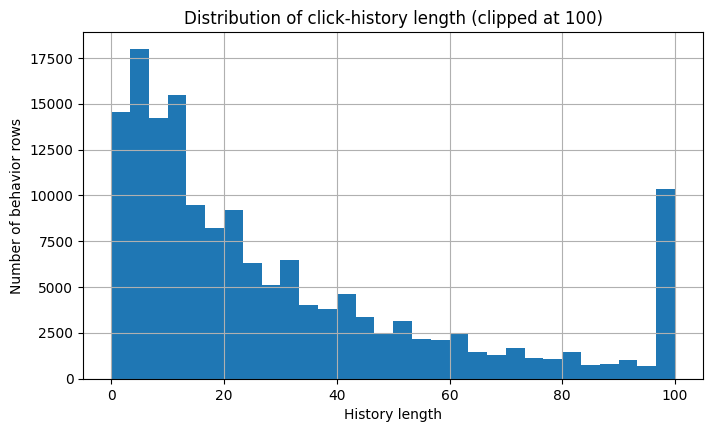

In [5]:
# Session / history length distribution
length_stats = behaviors["history_len"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("history_len")
display(length_stats)

fig, ax = plt.subplots()
behaviors["history_len"].clip(upper=100).hist(ax=ax, bins=30)
ax.set_title("Distribution of click-history length (clipped at 100)")
ax.set_xlabel("History length")
ax.set_ylabel("Number of behavior rows")
plt.show()


,metric,value
0,rows with at least 1 category in history,153727.00000
1,rows with at least 2 categories in history,149683.00000
2,median unique categories per row,7.00000
3,mean unique categories per row,6.99261


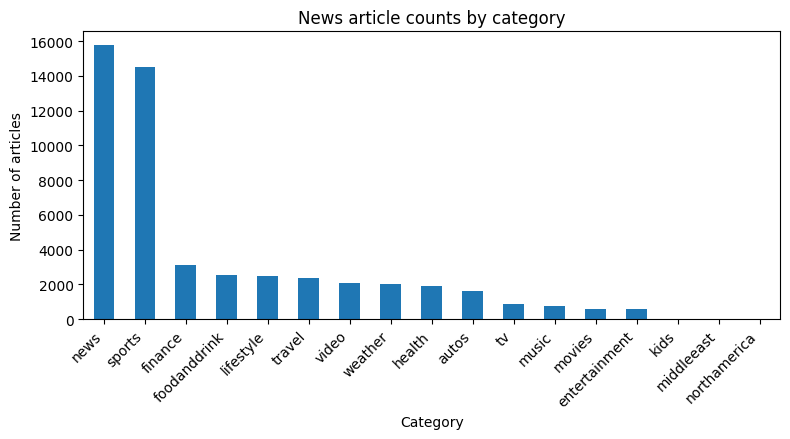

In [6]:
# Coverage of category sequences and category diversity per row.
behaviors["unique_categories_per_row"] = behaviors["category_sequence_raw"].apply(lambda seq: len(set(seq)))
coverage_summary = pd.DataFrame({
    "metric": [
        "rows with at least 1 category in history",
        "rows with at least 2 categories in history",
        "median unique categories per row",
        "mean unique categories per row",
    ],
    "value": [
        int((behaviors["category_seq_len"] >= 1).sum()),
        int((behaviors["unique_categories_per_row"] >= 2).sum()),
        float(behaviors["unique_categories_per_row"].median()),
        float(behaviors["unique_categories_per_row"].mean())
    ]
})
display(coverage_summary)

fig, ax = plt.subplots()
news["category"].value_counts().sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("News article counts by category")
ax.set_xlabel("Category")
ax.set_ylabel("Number of articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Takeaways

The additional EDA motivates the project design:

1. **Histories are long enough to support sequential analysis.**  
   Many rows contain non-trivial click histories, so sequence mining is not artificial here.

2. **Article-level mining is likely too sparse for a clean checkpoint notebook.**  
   There are many unique article IDs relative to repeated behavior, so direct article-level Apriori would mostly surface popularity effects or become computationally messy.

3. **Category-level mining is a good compromise.**  
   Categories are repeated often enough to produce stable supports, and the results are easy to interpret.

4. **This dataset has temporal structure.**  
   Click histories are ordered, which means course methods based on unordered sets leave information on the table.

## 3. Preprocessing Choices

Before mining patterns, I make several  preprocessing choices:

1. **Use category sequences instead of article IDs for the main mining runs.**  
   Why: better interpretability and much lower sparsity.

2. **Restrict to histories with length between 2 and 50 for feasibility experiments.**  
   Why:  
   - length 0 or 1 cannot support meaningful co-occurrence or sequential structure,  
   - extremely long histories can dominate support counts and increase computational cost.

3. **Remove duplicate categories within a transaction representation.**  
   Why: frequent itemset mining treats transactions as sets, so repeated category mentions within one row should not artificially inflate support.

4. **Compress consecutive duplicates for sequential mining.**  
   Why: repeated adjacent clicks from the same category can overwhelm sequential patterns with trivial self-repetition.


In [7]:
# Feasibility subset for mining.
min_hist_len = 2
max_hist_len = 50

mining_df = behaviors.loc[
    (behaviors["category_seq_len"] >= min_hist_len) &
    (behaviors["category_seq_len"] <= max_hist_len)
].copy()

def dedup_transaction(seq):
    return sorted(set(seq))

def compress_consecutive(seq):
    out = []
    for x in seq:
        if not out or out[-1] != x:
            out.append(x)
    return out

mining_df["category_transaction"] = mining_df["category_sequence_raw"].apply(dedup_transaction)
mining_df["category_sequence"] = mining_df["category_sequence_raw"].apply(compress_consecutive)

# Sample to keep Apriori-style feasibility tests lightweight but meaningful.
TRANSACTION_SAMPLE_N = 20000
SEQUENCE_SAMPLE_N = 12000

transaction_sample = mining_df.sample(
    n=min(TRANSACTION_SAMPLE_N, len(mining_df)),
    random_state=42
).copy()

sequence_sample = mining_df.sample(
    n=min(SEQUENCE_SAMPLE_N, len(mining_df)),
    random_state=42
).copy()

print("Rows in filtered mining_df:", len(mining_df))
print("Rows in transaction sample:", len(transaction_sample))
print("Rows in sequence sample:", len(sequence_sample))

display(transaction_sample[["history_len", "category_transaction", "category_sequence"]].head())


Rows in filtered mining_df: 120817
Rows in transaction sample: 20000
Rows in sequence sample: 12000


,history_len,category_transaction,category_sequence
85365,7,"[entertainment, finance, movies, sports, tv]","[movies, entertainment, finance, tv, finance, sports]"
127563,33,"[autos, finance, health, lifestyle, music, news, sports, travel, tv, video, weather]","[news, autos, finance, news, sports, travel, tv, autos, video, sports, autos, weather, autos, news, lifestyle, music..."
148211,25,"[autos, entertainment, health, lifestyle, movies, music, news, sports, travel, tv]","[health, sports, tv, news, health, music, tv, movies, lifestyle, travel, music, news, tv, music, entertainment, news..."
4508,11,"[finance, health, lifestyle, news]","[health, news, finance, lifestyle, finance, news, finance, news, finance]"
84223,5,"[movies, news, tv]","[news, tv, movies, news]"


## 4. Research Question Definition

### RQ1 (course)
**What frequent category-level co-click itemsets emerge in MIND-small under varying support thresholds?**

- **Task type:** Frequent itemset mining  
- **Relevant algorithm(s):** Apriori-style candidate generation and support counting  
- **Evaluation criteria:** support, number of itemsets found, interpretability  
- **Why this is interesting:** it reveals stable co-reading structure in user histories  
- **Why this is feasible:** category-level transactions are compact enough for support-based mining

### RQ2 (course)
**How do confidence and lift differ when evaluating category-level association rules in MIND-small?**

- **Task type:** Association rule mining  
- **Relevant algorithm(s):** rule generation from frequent itemsets  
- **Evaluation criteria:** support, confidence, lift, interpretability  
- **Why this is interesting:** high confidence can be misleading when a consequent is globally common  
- **Why this is feasible:** rules can be generated directly from RQ1 itemsets

### RQ3 (external)
**Do ordered category sequences reveal behavioral structure that is missed by unordered itemsets?**

- **Task type:** Sequential pattern mining  
- **Relevant algorithm(s):** PrefixSpan-style subsequence mining (external to course coverage used here)  
- **Evaluation criteria:** sequence support, diversity of discovered patterns, interpretability  
- **Why this is interesting:** MIND click histories are ordered and itemsets ignore that order  
- **Why this is feasible:** histories are long enough and category alphabet is small enough for a lightweight projected-pattern miner


## 5. RQ-to-Method Mapping Table

| RQ | Data mining task type | Algorithm(s) | Course vs external | Primary evaluation criteria |
|---|---|---|---|---|
| RQ1 | Frequent itemset mining | Apriori-style support counting | Course | support, number of itemsets, interpretability |
| RQ2 | Association rule mining | rule generation from frequent itemsets | Course | confidence, lift, support, interpretability |
| RQ3 | Sequential pattern mining | PrefixSpan-style projected subsequence mining | External | sequence support, diversity, interpretability |


## 6. Methodological Planning

### Course algorithms
- **Apriori-style itemset mining:** chosen because it is the clearest course-aligned baseline and makes the support-threshold tradeoff easy to explain.
- **Association-rule generation:** chosen because it directly extends itemset mining and allows comparison of confidence versus lift.

### External algorithm
- **PrefixSpan-style sequential mining:** chosen because course itemset methods ignore order, while MIND histories are fundamentally ordered.

### Baselines
- Unordered category transactions only
- High-support-only mining
- Comparing confidence-ranked rules to lift-ranked rules

### Main metrics
- **Support:** how common a pattern is
- **Confidence:** conditional reliability of a rule
- **Lift:** whether the rule is stronger than chance under item popularity
- **Interpretability:** whether the pattern is meaningful in the news-consumption setting

### Main risks
- Support thresholds that are too high may only surface very generic patterns such as `news`
- Support thresholds that are too low may generate too many patterns
- Sequential mining can over-emphasize repeated generic categories unless the sequences are cleaned carefully


## 7. Feasibility Experiment for RQ1: Frequent Itemset Mining

I implement a compact Apriori-style miner using pure Python.  
I intentionally keep `max_len=3` for this checkpoint because the goal is RQ formation, and triples already show whether interesting higher-order structure exists.

In [8]:
def mine_frequent_itemsets(transactions, min_support=0.2, max_len=3):
    """
    Simple Apriori-style frequent itemset miner.
    Returns:
        itemsets_df: DataFrame with columns [itemset, k, support, count]
        support_map: dict from tuple(itemset) -> support
    """
    n = len(transactions)
    assert n > 0, "Transactions must be non-empty."

    itemsets_records = []
    support_map = {}

    # frequent (k-1)-itemsets used for Apriori pruning
    prev_frequents = {tuple([item]) for item in sorted({x for t in transactions for x in t})}

    for k in range(1, max_len + 1):
        counts = Counter()

        for transaction in transactions:
            t = sorted(set(transaction))
            if len(t) < k:
                continue

            if k == 1:
                for item in t:
                    counts[(item,)] += 1
            else:
                for cand in combinations(t, k):
                    # Apriori pruning: every (k-1)-subset must already be frequent
                    if all(tuple(sorted(sub)) in prev_frequents for sub in combinations(cand, k - 1)):
                        counts[cand] += 1

        current_frequents = set()
        for cand, cnt in counts.items():
            support = cnt / n
            if support >= min_support:
                support_map[cand] = support
                itemsets_records.append({
                    "itemset": cand,
                    "k": k,
                    "count": cnt,
                    "support": support
                })
                current_frequents.add(cand)

        prev_frequents = current_frequents
        if not prev_frequents:
            break

    itemsets_df = pd.DataFrame(itemsets_records).sort_values(
        by=["k", "support", "itemset"], ascending=[True, False, True]
    ).reset_index(drop=True)

    return itemsets_df, support_map


In [9]:
transactions = transaction_sample["category_transaction"].tolist()

thresholds = [0.30, 0.20, 0.10]
threshold_summaries = []

for threshold in thresholds:
    itemsets_df, support_map = mine_frequent_itemsets(
        transactions=transactions,
        min_support=threshold,
        max_len=3
    )
    threshold_summaries.append({
        "min_support": threshold,
        "num_itemsets": len(itemsets_df),
        "num_singletons": int((itemsets_df["k"] == 1).sum()) if len(itemsets_df) else 0,
        "num_pairs": int((itemsets_df["k"] == 2).sum()) if len(itemsets_df) else 0,
        "num_triples": int((itemsets_df["k"] == 3).sum()) if len(itemsets_df) else 0
    })

threshold_summary_df = pd.DataFrame(threshold_summaries)
display(threshold_summary_df)


,min_support,num_itemsets,num_singletons,num_pairs,num_triples
0,0.3,36,12,18,6
1,0.2,104,13,45,46
2,0.1,282,14,79,189


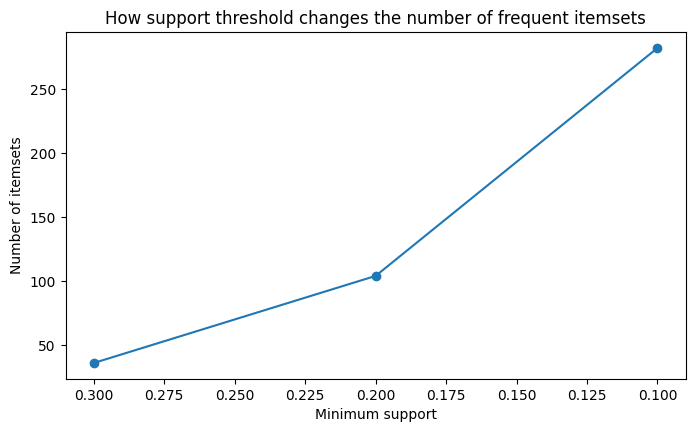

In [10]:
fig, ax = plt.subplots()
ax.plot(threshold_summary_df["min_support"], threshold_summary_df["num_itemsets"], marker="o")
ax.set_title("How support threshold changes the number of frequent itemsets")
ax.set_xlabel("Minimum support")
ax.set_ylabel("Number of itemsets")
ax.invert_xaxis()
plt.show()


In [11]:
rq1_itemsets_df, rq1_support_map = mine_frequent_itemsets(
    transactions=transactions,
    min_support=0.20,
    max_len=3
)

print("Top frequent pairs at min_support = 0.20")
display(rq1_itemsets_df[rq1_itemsets_df["k"] == 2].head(10))

print("Top frequent triples at min_support = 0.20")
display(rq1_itemsets_df[rq1_itemsets_df["k"] == 3].head(10))


Top frequent pairs at min_support = 0.20


,itemset,k,count,support
13,"(lifestyle, news)",2,11785,0.58925
14,"(news, sports)",2,11493,0.57465
15,"(news, tv)",2,10782,0.53910
16,"(finance, news)",2,10203,0.51015
17,"(lifestyle, tv)",2,8672,0.43360
18,"(lifestyle, sports)",2,8319,0.41595
19,"(sports, tv)",2,7930,0.39650
20,"(finance, lifestyle)",2,7834,0.39170
21,"(movies, news)",2,7620,0.38100
22,"(finance, sports)",2,7509,0.37545


Top frequent triples at min_support = 0.20


,itemset,k,count,support
58,"(lifestyle, news, tv)",3,8068,0.40340
59,"(lifestyle, news, sports)",3,7812,0.39060
60,"(news, sports, tv)",3,7421,0.37105
61,"(finance, lifestyle, news)",3,7416,0.37080
62,"(finance, news, sports)",3,7135,0.35675
63,"(finance, news, tv)",3,6574,0.32870
64,"(lifestyle, sports, tv)",3,5876,0.29380
65,"(health, lifestyle, news)",3,5867,0.29335
66,"(foodanddrink, lifestyle, news)",3,5779,0.28895
67,"(lifestyle, movies, news)",3,5767,0.28835




The feasibility run shows that support-threshold tuning materially changes what patterns are discovered.

A threshold that is too high mostly captures dominant broad-interest categories; a lower threshold reveals more diverse cross-category structure.


## 8. Feasibility Experiment for RQ2: Association Rules

Next I generate rules from the frequent itemsets found above.

I compare confidence and lift which is important for MIND-small because broad categories like `news` are extremely common.  
That means a rule with high confidence may simply point to a globally frequent consequent and lift helps detect whether the relationship is stronger than expected under base rates.


In [12]:
def generate_association_rules(support_map, min_confidence=0.65):
    """
    Generate association rules from frequent itemsets.
    Only rules whose antecedent and consequent supports are known can be scored.
    """
    records = []

    for itemset, supp_ab in support_map.items():
        if len(itemset) < 2:
            continue

        itemset_set = set(itemset)
        for r in range(1, len(itemset)):
            for antecedent in combinations(itemset, r):
                antecedent = tuple(sorted(antecedent))
                consequent = tuple(sorted(itemset_set - set(antecedent)))

                supp_a = support_map.get(antecedent)
                supp_b = support_map.get(consequent)

                if supp_a is None or supp_b is None:
                    continue

                confidence = supp_ab / supp_a
                lift = confidence / supp_b

                if confidence >= min_confidence:
                    records.append({
                        "antecedent": antecedent,
                        "consequent": consequent,
                        "support": supp_ab,
                        "confidence": confidence,
                        "lift": lift,
                        "antecedent_size": len(antecedent),
                        "consequent_size": len(consequent)
                    })

    rules_df = pd.DataFrame(records).sort_values(
        by=["lift", "confidence", "support"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return rules_df


In [13]:
rules_df = generate_association_rules(rq1_support_map, min_confidence=0.65)

print("Number of rules at min_support = 0.20 and min_confidence = 0.65:", len(rules_df))
display(rules_df.head(12))


Number of rules at min_support = 0.20 and min_confidence = 0.65: 153


,antecedent,consequent,support,confidence,lift,antecedent_size,consequent_size
0,"(music,)","(news, tv)",0.22640,0.725176,1.345161,1,2
1,"(entertainment, lifestyle)","(tv,)",0.20480,0.790581,1.336570,2,1
2,"(lifestyle, movies)","(tv,)",0.24185,0.786760,1.330110,2,1
3,"(music, news)","(tv,)",0.22640,0.782714,1.323270,2,1
4,"(travel,)","(finance, news)",0.21295,0.667137,1.307726,1,2
5,"(news, travel)","(finance,)",0.21295,0.711850,1.301848,2,1
6,"(music,)","(tv,)",0.23985,0.768258,1.298829,1,1
7,"(entertainment,)","(news, tv)",0.23435,0.697055,1.292998,1,2
8,"(entertainment, news)","(tv,)",0.23435,0.763728,1.291172,2,1
9,"(movies, sports)","(tv,)",0.21875,0.761134,1.286787,2,1


In [14]:
# Compare simple 1-to-1 rules ranked by confidence versus lift.
simple_rules = rules_df[
    (rules_df["antecedent_size"] == 1) &
    (rules_df["consequent_size"] == 1)
].copy()

top_by_confidence = simple_rules.sort_values(
    by=["confidence", "lift", "support"],
    ascending=[False, False, False]
).head(8)

top_by_lift = simple_rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).head(8)

print("Top simple rules ranked by confidence")
display(top_by_confidence)

print("Top simple rules ranked by lift")
display(top_by_lift)


Top simple rules ranked by confidence


,antecedent,consequent,support,confidence,lift,antecedent_size,consequent_size
115,"(video,)","(news,)",0.21910,0.946641,1.066217,1,1
130,"(travel,)","(news,)",0.29915,0.937187,1.055569,1,1
134,"(finance,)","(news,)",0.51015,0.932974,1.050824,1,1
137,"(autos,)","(news,)",0.28080,0.930263,1.047771,1,1
142,"(music,)","(news,)",0.28925,0.926489,1.043520,1,1
143,"(foodanddrink,)","(news,)",0.36330,0.922081,1.038555,1,1
144,"(movies,)","(news,)",0.38100,0.921291,1.037665,1,1
146,"(health,)","(news,)",0.37000,0.916295,1.032038,1,1


Top simple rules ranked by lift


,antecedent,consequent,support,confidence,lift,antecedent_size,consequent_size
6,"(music,)","(tv,)",0.23985,0.768258,1.298829,1,1
13,"(travel,)","(finance,)",0.22200,0.695489,1.271925,1,1
14,"(entertainment,)","(tv,)",0.25195,0.749405,1.266957,1,1
16,"(autos,)","(finance,)",0.20790,0.688753,1.259606,1,1
24,"(movies,)","(tv,)",0.30300,0.732680,1.238682,1,1
42,"(foodanddrink,)","(lifestyle,)",0.30810,0.781980,1.201844,1,1
43,"(travel,)","(lifestyle,)",0.24935,0.781172,1.200602,1,1
45,"(foodanddrink,)","(finance,)",0.25745,0.653426,1.195001,1,1



The preliminary rule results already show that this question is worthwile to explore because rules ranked by confidence are often dominated by very common consequents, and rules ranked by lift surface more specific cross-category relationships.


Overall, this question looks at how evaluation criteria can change what we consider a “good” pattern.


## 9. Feasibility Experiment for RQ3: PrefixSpan-style Sequential Pattern Mining

For the external-method question, I implement a lightweight PrefixSpan-style projected pattern-growth miner. This sequential miner goes beyond unordered transactions by explicitly respecting order.


I use a simplified PrefixSpan-style algorithm as the external method for sequential pattern mining. PrefixSpan is a well-established algorithm that discovers frequent subsequences by recursively projecting the database based on prefix growth. I implement a lightweight version tailored to our dataset, limiting pattern length and optimizing for interpretability and feasibility within the notebook environment. This allows me to capture ordering effects in user behavior that are not detectable using unordered frequent itemsets.

This works well for the MIND dataset because
MIND histories are ordered click sequences.  
If order matters, then an unordered basket model throws away information.

I use `max_len = 3` in the feasibility stage because it keeps the notebook computationally manageable at this exploratory stage.


In [15]:
def prefixspan_style_mine(sequences, min_support_count=600, max_len=3):
    """
    Lightweight PrefixSpan-style subsequence miner.
    Support counts the number of sequences containing the pattern as an ordered subsequence.
    """
    patterns = {}

    def recurse(projected_db, prefix):
        if len(prefix) >= max_len:
            return

        extension_counts = Counter()

        # Count each possible next item at most once per sequence for support semantics.
        for seq, start_idx in projected_db:
            seen_in_this_sequence = set()
            for pos in range(start_idx, len(seq)):
                item = seq[pos]
                if item not in seen_in_this_sequence:
                    extension_counts[item] += 1
                    seen_in_this_sequence.add(item)

        for item, cnt in extension_counts.items():
            if cnt >= min_support_count:
                new_prefix = prefix + (item,)
                patterns[new_prefix] = cnt

                new_projected_db = []
                for seq, start_idx in projected_db:
                    for pos in range(start_idx, len(seq)):
                        if seq[pos] == item:
                            new_projected_db.append((seq, pos + 1))
                            break

                recurse(new_projected_db, new_prefix)

    initial_projected_db = [(seq, 0) for seq in sequences if len(seq) > 0]
    recurse(initial_projected_db, tuple())

    records = [
        {"pattern": pat, "k": len(pat), "count": cnt, "support": cnt / len(sequences)}
        for pat, cnt in patterns.items()
    ]
    patterns_df = pd.DataFrame(records).sort_values(
        by=["k", "support", "pattern"],
        ascending=[True, False, True]
    ).reset_index(drop=True)

    return patterns_df


In [16]:
sequences = sequence_sample["category_sequence"].tolist()
seq_patterns_df = prefixspan_style_mine(
    sequences=sequences,
    min_support_count=600,
    max_len=3
)

print("Total sequential patterns found:", len(seq_patterns_df))
print("Top length-2 patterns:")
display(seq_patterns_df[seq_patterns_df["k"] == 2].head(12))

print("Top length-3 patterns:")
display(seq_patterns_df[seq_patterns_df["k"] == 3].head(12))


Total sequential patterns found: 1548
Top length-2 patterns:


,pattern,k,count,support
14,"(news, news)",2,8151,0.679250
15,"(news, lifestyle)",2,6323,0.526917
16,"(sports, news)",2,6213,0.517750
17,"(lifestyle, news)",2,6193,0.516083
18,"(news, sports)",2,6003,0.500250
19,"(tv, news)",2,5713,0.476083
20,"(news, tv)",2,5475,0.456250
21,"(finance, news)",2,5408,0.450667
22,"(news, finance)",2,5359,0.446583
23,"(sports, sports)",2,4835,0.402917


Top length-3 patterns:


,pattern,k,count,support
198,"(news, news, news)",3,6005,0.500417
199,"(news, lifestyle, news)",3,4988,0.415667
200,"(news, sports, news)",3,4860,0.405000
201,"(sports, news, news)",3,4683,0.390250
202,"(news, news, lifestyle)",3,4654,0.387833
203,"(news, news, sports)",3,4449,0.370750
204,"(news, finance, news)",3,4447,0.370583
205,"(lifestyle, news, news)",3,4435,0.369583
206,"(news, tv, news)",3,4278,0.356500
207,"(tv, news, news)",3,4223,0.351917


In [17]:
# Compare unordered frequent pairs with ordered sequential pairs.
top_itemset_pairs = rq1_itemsets_df[rq1_itemsets_df["k"] == 2][["itemset", "support"]].head(10).copy()
top_seq_pairs = seq_patterns_df[seq_patterns_df["k"] == 2][["pattern", "support"]].head(10).copy()

print("Top unordered itemset pairs")
display(top_itemset_pairs)

print("Top ordered sequential pairs")
display(top_seq_pairs)


Top unordered itemset pairs


,itemset,support
13,"(lifestyle, news)",0.58925
14,"(news, sports)",0.57465
15,"(news, tv)",0.53910
16,"(finance, news)",0.51015
17,"(lifestyle, tv)",0.43360
18,"(lifestyle, sports)",0.41595
19,"(sports, tv)",0.39650
20,"(finance, lifestyle)",0.39170
21,"(movies, news)",0.38100
22,"(finance, sports)",0.37545


Top ordered sequential pairs


,pattern,support
14,"(news, news)",0.679250
15,"(news, lifestyle)",0.526917
16,"(sports, news)",0.517750
17,"(lifestyle, news)",0.516083
18,"(news, sports)",0.500250
19,"(tv, news)",0.476083
20,"(news, tv)",0.456250
21,"(finance, news)",0.450667
22,"(news, finance)",0.446583
23,"(sports, sports)",0.402917



The sequential feasibility run shows that the ordered version is not equivalent to the unordered one:

- unordered itemsets tell us **which categories co-occur**,
- sequential patterns tell us **which categories tend to appear before others**.

That difference what RQ3 is trying to test, so RQ3 is both motivated and non-trivial.


## 10. Tests and Validation Checks
I ran a few targeted checks:

1. lowering support should not produce fewer itemsets than raising support,
2. association-rule lifts should be finite and positive,
3. sequential mining should produce at least some non-trivial length-2 patterns,
4. the filtered dataset should actually contain enough signal to justify the proposed methods.


In [18]:
# 1. Support-threshold monotonicity
num_itemsets_high = threshold_summary_df.loc[threshold_summary_df["min_support"] == 0.30, "num_itemsets"].iloc[0]
num_itemsets_mid = threshold_summary_df.loc[threshold_summary_df["min_support"] == 0.20, "num_itemsets"].iloc[0]
num_itemsets_low = threshold_summary_df.loc[threshold_summary_df["min_support"] == 0.10, "num_itemsets"].iloc[0]

assert num_itemsets_high <= num_itemsets_mid <= num_itemsets_low, "Frequent itemsets should grow as support decreases."

# 2. Rule sanity checks
assert len(rules_df) > 0, "Expected at least one association rule."
assert np.isfinite(rules_df["lift"]).all(), "All rule lifts should be finite."
assert (rules_df["lift"] > 0).all(), "All rule lifts should be positive."

# 3. Sequential pattern sanity checks
assert len(seq_patterns_df[seq_patterns_df["k"] == 2]) > 0, "Expected non-trivial sequential length-2 patterns."

# 4. Data signal checks
assert mining_df["category_seq_len"].median() >= 5, "Sequences are unexpectedly short for this plan."
assert news["category"].nunique() >= 10, "Category space is too small to support meaningful diversity."

print("All validation checks passed.")


All validation checks passed.


## 11. Final Method and Metric Plan

### Planned methods
- **RQ1:** Apriori-style frequent itemset mining on category transactions, with support-threshold comparison
- **RQ2:** Association rules derived from RQ1 itemsets, with explicit comparison between confidence-ranked and lift-ranked rules
- **RQ3:** PrefixSpan-style sequential mining on cleaned category sequences

### Planned metrics
- **Support:** pattern prevalence
- **Confidence:** conditional rule strength
- **Lift:** rule strength adjusted for popularity
- **Interpretability / diversity:** whether the discovered patterns are meaningfully different and explainable in the news domain

### Planned baselines
- High-support-only mining
- Unordered itemsets versus ordered sequences

### Feasibility conclusion
The initial runs in this notebook show that:
- itemset mining is computationally feasible on sampled category transactions,
- rule generation produces non-trivial results,
- sequential mining finds ordered patterns that unordered methods miss.

## Summary

**Project scope recap.**  
This project uses the MIND-small news recommendation dataset. Additional EDA shows that user click histories are long enough to support temporal analysis, article-level behavior is sparse, and category-level aggregation yields a compact and interpretable representation. Based on those observations, I model each history both as:
- an **unordered transaction** of categories for itemset/rule mining, and
- an **ordered sequence** of categories for sequential mining.

**RQ1. What frequent category-level co-click itemsets emerge under varying support thresholds?**  
This is a frequent itemset mining task using an Apriori-style method. It will be evaluated using support, the number of itemsets discovered, and interpretability. The motivation is that MIND-small histories contain repeated category co-occurrence, but the choice of support threshold changes which structures are considered stable enough to keep.

**RQ2. How do confidence and lift differ when evaluating category-level association rules in MIND-small?**  
This is an association rule mining task built on the frequent itemsets from RQ1. It will be evaluated using support, confidence, lift, and interpretability. The motivation is that broad categories such as `news` are globally common, so high confidence alone may overstate rule quality, whereas lift can better reveal relationships that are stronger than chance.

**RQ3. Do ordered category sequences reveal behavioral structure that is missed by unordered itemsets?**  
This is a sequential pattern mining task using a PrefixSpan-style projected pattern-growth method. It will be evaluated using sequence support, pattern diversity, and interpretability. The motivation is that MIND-small histories are inherently ordered; therefore, sequential methods may reveal topical progression that is invisible to unordered itemset mining.

Overall, the three RQs satisfy the checkpoint requirement of using both course techniques and at least one external method, while remaining tightly grounded in the actual structure of the MIND-small dataset.


## Collaboration Declaration

On my honor, I declare the following resources:

- **Collaborators:** None.

- **Web Sources:** MIND project page: https://msnews.github.io/
Wu et al. (2020) MIND paper.

- **AI Tools:** ChatGPT was used to help write the code, polish writing, structure the notebook, improve EDA and code clarity.
All final decisions, research questions, assumptions, and justifications in this notebook were reviewed and edited by me.

- **Citations**  
  - Wu, F., Qiao, Y., Chen, J.-H., Wu, C., Qi, T., Lian, J., Liu, D., Xie, X., Gao, J., Wu, W., & Zhou, M. (2020). MIND: A Large-scale Dataset for News Recommendation. ACL.
  - Agrawal & Srikant, *Fast Algorithms for Mining Association Rules*  
  - Pei et al., *PrefixSpan: Mining Sequential Patterns Efficiently by Prefix-Projected Pattern Growth*